In [86]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from helper_functions import plot_decision_boundary
from torchmetrics import Accuracy

In [87]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Exercises - II

(Date - 14/May/2026)

1.Create a multi-class dataset using the spirals data creation function from CS231n (see below for the code).
* Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).
* Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).
* Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like).
* Plot the decision boundaries on the spirals dataset from your model predictions, the plot_decision_boundary() function should work for this dataset too.

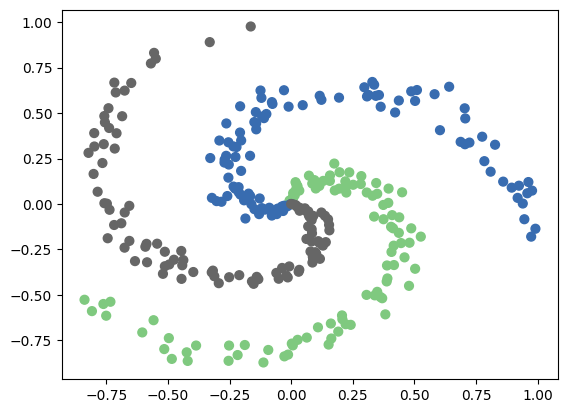

In [88]:
# Code for creating a spiral dataset from CS231n
import numpy as np
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
coords = np.zeros((N*K,D)) # data matrix (each row = single example)
labels = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  coords[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  labels[ix] = j
# lets visualize the data
plt.scatter(coords[:, 0], coords[:, 1], c=labels, s=40, cmap=plt.cm.Accent)
plt.show()


In [89]:
coords.shape, labels.shape

((300, 2), (300,))

In [ ]:
coords = torch.from_numpy(coords).type(torch.float)
labels = torch.from_numpy(labels).type(torch.LongTensor)

# train_coords, train_labels = coords[:250], labels[:250] -> Wrong - Because there is no shuffle
# test_coords, test_labels = coords[250:], labels[250:] -> Wrong - Because there is no shuffle

train_coords, test_coords, train_labels, test_labels = train_test_split(coords, labels, train_size=0.8, random_state=42, shuffle=True)

# Note - setting shuffle = True is extremely important, else our model will only learn for the 1st and 2nd class. And when we will check the train accuracy and loss, it will be good, but the test loss and accuracy will be traumatic

In [91]:
train_coords.shape, train_labels.shape, test_coords.shape, test_labels.shape

(torch.Size([240, 2]),
 torch.Size([240]),
 torch.Size([60, 2]),
 torch.Size([60]))

In [92]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layers = nn.Sequential(
            nn.Linear(in_features=2, out_features=8),
            nn.ReLU(),
            nn.Tanh(),
            # nn.Sigmoid(),
            nn.Linear(in_features=8, out_features=8),
            nn.ReLU(),
            nn.Tanh(),
            # nn.Sigmoid(),
            nn.Linear(in_features=8, out_features=8),
            nn.ReLU(),
            nn.Tanh(),
            # nn.Sigmoid(),
            nn.Linear(in_features=8, out_features=3)
        )
    
    def forward(self, x):
        return self.layers(x)
        
model = Model()
model.state_dict()

OrderedDict([('layers.0.weight',
              tensor([[-0.2411, -0.3094],
                      [ 0.1483,  0.0507],
                      [-0.4685,  0.2071],
                      [-0.3396, -0.3396],
                      [-0.4455, -0.3817],
                      [-0.5601,  0.5439],
                      [ 0.0205,  0.6994],
                      [-0.5906,  0.5347]])),
             ('layers.0.bias',
              tensor([-0.4004, -0.2745, -0.2565,  0.4755,  0.1937,  0.1492, -0.1483, -0.0249])),
             ('layers.3.weight',
              tensor([[ 0.2537, -0.0168, -0.0218,  0.1412,  0.1617, -0.0946, -0.2565,  0.1831],
                      [-0.1864, -0.2691,  0.0177, -0.2398,  0.2204,  0.0208,  0.1863,  0.3076],
                      [ 0.1759, -0.2973, -0.2073, -0.1927,  0.3089, -0.1692,  0.0861, -0.2586],
                      [ 0.1561,  0.1070,  0.1429,  0.0460,  0.2857,  0.2038, -0.2364, -0.2595],
                      [-0.0667, -0.2626, -0.3208, -0.3332, -0.1206,  0.3122,  0.066

In [93]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.1)

In [101]:
epochs = 100

metric = Accuracy(task="multiclass", num_classes = 3)
for epoch in range(epochs):
    model.train()

    train_logits = model(train_coords)
    train_preds = train_logits.argmax(dim=1)

    train_loss = loss_fn(train_logits, train_labels)
    train_acc = metric(train_preds, train_labels) * 100

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(test_coords)
        test_preds = test_logits.argmax(dim=1)

        test_loss = loss_fn(test_logits, test_labels)
        test_acc = metric(test_preds, test_labels) * 100
    
    if epoch % 10 == 0:
        print(f"{epoch}. Train Loss : {train_loss} | Train acc : {train_acc} | Test Loss : {test_loss} | Test acc : {test_acc}")

train_loss

0. Train Loss : 0.04968036711215973 | Train acc : 97.91667175292969 | Test Loss : 0.026919370517134666 | Test acc : 100.0
10. Train Loss : 0.04285674914717674 | Train acc : 98.33333587646484 | Test Loss : 0.021095240488648415 | Test acc : 100.0
20. Train Loss : 0.04610707238316536 | Train acc : 98.33333587646484 | Test Loss : 0.03083646669983864 | Test acc : 98.33333587646484
30. Train Loss : 0.04806864634156227 | Train acc : 98.33333587646484 | Test Loss : 0.017594754695892334 | Test acc : 100.0
40. Train Loss : 0.04364022985100746 | Train acc : 97.91667175292969 | Test Loss : 0.014127413742244244 | Test acc : 100.0
50. Train Loss : 0.041524529457092285 | Train acc : 97.91667175292969 | Test Loss : 0.01150595024228096 | Test acc : 100.0
60. Train Loss : 0.034581806510686874 | Train acc : 98.75 | Test Loss : 0.008843067102134228 | Test acc : 100.0
70. Train Loss : 0.042661990970373154 | Train acc : 98.33333587646484 | Test Loss : 0.01559602003544569 | Test acc : 100.0
80. Train Loss : 

tensor(0.0333, grad_fn=<NllLossBackward0>)

In [102]:
model.eval()
with torch.inference_mode():
    test_logits = model(test_coords)
    test_preds = test_logits.argmax(dim=1)

    test_loss = loss_fn(test_logits, test_labels)
    test_acc = metric(test_preds, test_labels) * 100

test_loss

tensor(0.0049)

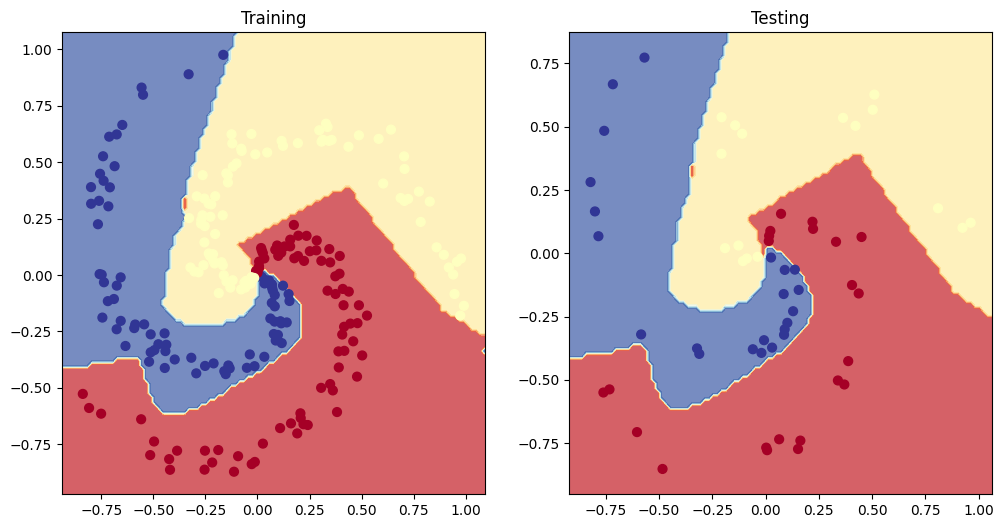

In [103]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Training")
plot_decision_boundary(model, train_coords, train_labels)
plt.subplot(1,2,2)
plt.title("Testing")
plot_decision_boundary(model, test_coords, test_labels)

15/May/2026 - 17/May/2026 -> Extra-curriculum